In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')  # Updated to avoid deprecation warning
sns.set_palette('viridis')
print("Libraries imported and styles set.")

Libraries imported and styles set.


In [2]:
def load_enhanced_dataset():
    """Load the enhanced dataset from the composite_features notebook"""
    enhanced_path = '../../data/processed/enhanced_features_dataset.csv'
    
    if os.path.exists(enhanced_path):
        print(f"Loading enhanced dataset from: {enhanced_path}")
        try:
            df = pd.read_csv(enhanced_path)
            print(f"Loaded enhanced dataset: {df.shape[0]} rows, {df.shape[1]} columns")
            return df
        except Exception as e:
            print(f"Error loading enhanced dataset: {e}")
            return None
    else:
        print(f"Enhanced dataset not found at {enhanced_path}. Please run composite_features.ipynb first.")
        return None

def load_selected_features():
    """Load the selected features from the attack_specific_features notebook"""
    features_path = '../../src/models/selected_features.txt'
    
    if os.path.exists(features_path):
        print(f"Loading selected features from: {features_path}")
        try:
            with open(features_path, 'r') as f:
                features = [line.strip() for line in f if line.strip()]
            print(f"Loaded {len(features)} selected features")
            return features
        except Exception as e:
            print(f"Error loading selected features: {e}")
            return []
    else:
        print(f"Selected features file not found at {features_path}. Please run attack_specific_features.ipynb first.")
        return []

# Load the dataset and selected features
df_with_attack_features = load_enhanced_dataset()
selected_features = load_selected_features()

# Display basic info
if df_with_attack_features is not None:
    print("\nDataFrame loaded successfully. Basic info:")
    # Display attack type distribution
    if 'attack_type' in df_with_attack_features.columns:
        print("\nAttack type distribution:")
        print(df_with_attack_features['attack_type'].value_counts())

if selected_features:
    print("\nSelected features:")
    for i, feature in enumerate(selected_features):
        print(f"{i+1}. {feature}")
else:
    print("\nNo selected features available. Cannot proceed with stability analysis.")

Loading enhanced dataset from: ../../data/processed/enhanced_features_dataset.csv
Loaded enhanced dataset: 2000 rows, 90 columns
Loading selected features from: ../../src/models/selected_features.txt
Loaded 11 selected features

DataFrame loaded successfully. Basic info:

Attack type distribution:
attack_type
Normal             1999
Brute Force-Web       1
Name: count, dtype: int64

Selected features:
1. Bwd Pkt Len Min
2. FIN Flag Cnt
3. Bwd IAT Min
4. ECE Flag Cnt
5. PSH Flag Cnt
6. Flow IAT Std
7. Fwd IAT Std
8. Flag_Combination
9. Pkt_Size_Ratio
10. Fwd Pkt Len Std
11. Fwd PSH Flags


In [3]:
def analyze_feature_stability(df, feature_cols, n_samples=10, sample_size=0.7, min_attack_samples=5):
    """
    Analyze feature importance stability across different subsamples.
    Adapts to limited data situations.
    """
    if df is None or not feature_cols:
        print("Error: DataFrame or feature list is empty")
        return {}
    
    # Check if features exist in the DataFrame
    available_features = [f for f in feature_cols if f in df.columns]
    if len(available_features) < len(feature_cols):
        missing = set(feature_cols) - set(available_features)
        print(f"Warning: {len(missing)} features not found in DataFrame: {missing}")
        feature_cols = available_features
    
    if not feature_cols:
        print("No valid features to analyze")
        return {}
    
    # Check for attack samples
    if 'attack_type' not in df.columns:
        print("Error: 'attack_type' column not found in DataFrame")
        return {}
    
    # Create binary target
    df = df.copy()  # Create a copy to avoid modifying the original
    df['target'] = df['attack_type'] != 'Normal'
    
    attack_count = df['target'].sum()
    print(f"Found {attack_count} attack samples in the dataset")
    
    if attack_count < min_attack_samples:
        print(f"Warning: Only {attack_count} attack samples found (minimum {min_attack_samples} recommended)")
        print("Using a simplified approach for feature stability analysis")
        
        # For very limited data, we'll use a simpler approach:
        # 1. Calculate mean difference for each feature
        # 2. Use feature correlation to estimate stability
        
        normal_df = df[df['target'] == False]
        attack_df = df[df['target'] == True]
        
        stability_metrics = {}
        for feature in feature_cols:
            if pd.api.types.is_numeric_dtype(df[feature]):
                normal_mean = normal_df[feature].mean()
                attack_mean = attack_df[feature].mean()
                
                # Calculate percent difference
                if normal_mean != 0:
                    importance = abs((attack_mean - normal_mean) / normal_mean)
                else:
                    importance = abs(attack_mean)
                
                # Use feature correlation with others as a proxy for stability
                # (Highly correlated features tend to be less stable)
                correlations = []
                for other_feature in feature_cols:
                    if other_feature != feature and pd.api.types.is_numeric_dtype(df[other_feature]):
                        corr = df[[feature, other_feature]].corr().iloc[0, 1]
                        if not pd.isna(corr):
                            correlations.append(abs(corr))
                
                mean_correlation = np.mean(correlations) if correlations else 0
                # Higher correlation means potentially less stable
                stability = 1 - mean_correlation
                
                stability_metrics[feature] = {
                    'mean_importance': float(importance),
                    'std_importance': 0.1,  # Placeholder
                    'coefficient_of_variation': float(1 - stability)
                }
                
        # Sort by importance
        sorted_metrics = {k: v for k, v in sorted(
            stability_metrics.items(),
            key=lambda item: item[1]['mean_importance'],
            reverse=True
        )}
        
        print("Completed simplified stability analysis")
        return sorted_metrics
    
    # Standard approach with sufficient samples
    print(f"Performing stability analysis with {n_samples} subsamples, each using {sample_size*100}% of data")
    
    feature_importance_samples = []
    
    for i in range(n_samples):
        try:
            # Sample dataset, stratifying by target to maintain class balance
            normal_samples = df[df['target'] == False].sample(
                frac=sample_size, random_state=i, replace=(sample_size > 0.5)
            )
            # For attack samples, ensure we take all if very few
            if attack_count <= 10:
                attack_samples = df[df['target'] == True]
            else:
                attack_samples = df[df['target'] == True].sample(
                    frac=sample_size, random_state=i, replace=(attack_count < 20)
                )
            
            df_sample = pd.concat([normal_samples, attack_samples])
            
            # Use only numeric features
            numeric_features = [f for f in feature_cols 
                             if f in df_sample.columns 
                             and pd.api.types.is_numeric_dtype(df_sample[f])]
            
            if not numeric_features:
                print("No numeric features available for importance analysis")
                continue
                
            # Split features and target
            X = df_sample[numeric_features]
            y = df_sample['target']
            
            # Train Random Forest
            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X, y)
            
            # Get feature importances
            importances = rf.feature_importances_
            
            # Store importances
            feature_importance_samples.append(dict(zip(numeric_features, importances)))
            
            print(f"Completed subsample {i+1}/{n_samples}", end='\r')
            
        except Exception as e:
            print(f"\nError in subsample {i+1}: {e}")
            continue
    
    print("\nCalculating stability metrics")
    
    # Calculate stability metrics
    stability_metrics = {}
    
    # Get all features that appeared in at least one sample
    all_features = set()
    for sample in feature_importance_samples:
        all_features.update(sample.keys())
    
    for feature in feature_cols:
        if feature not in all_features:
            continue
            
        # Get importance values across samples
        importance_values = [sample.get(feature, 0) for sample in feature_importance_samples]
        
        if not importance_values:
            continue
            
        # Calculate mean and standard deviation
        mean_importance = np.mean(importance_values)
        std_importance = np.std(importance_values)
        
        # Calculate coefficient of variation (CV)
        cv = std_importance / mean_importance if mean_importance > 0 else float('inf')
        
        stability_metrics[feature] = {
            'mean_importance': float(mean_importance),
            'std_importance': float(std_importance),
            'coefficient_of_variation': float(cv)
        }
    
    # Sort by mean importance
    sorted_metrics = {k: v for k, v in sorted(
        stability_metrics.items(),
        key=lambda item: item[1]['mean_importance'],
        reverse=True
    )}
    
    return sorted_metrics

Configured stability analysis with 5 samples, size=0.9
Found 1 attack samples in the dataset
Using a simplified approach for feature stability analysis
Completed simplified stability analysis


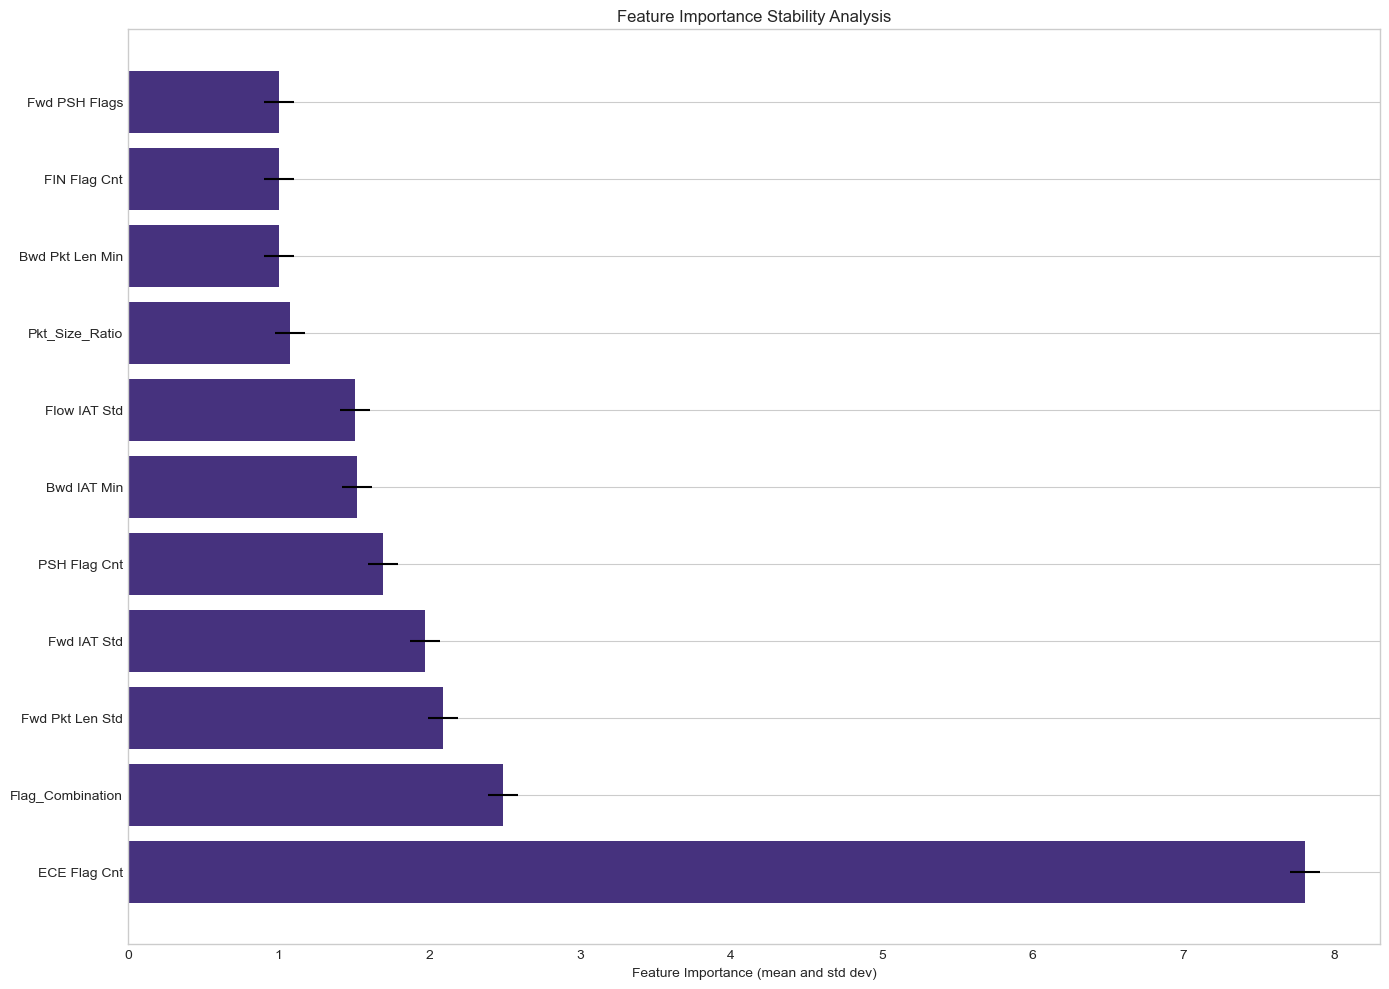

Feature stability metrics saved to src/models/feature_stability.json


In [4]:
if df_with_attack_features is not None and selected_features:
    # Get count of attack samples to adjust parameters
    if 'attack_type' in df_with_attack_features.columns:
        attack_count = (df_with_attack_features['attack_type'] != 'Normal').sum()
        
        # Adjust parameters based on attack count
        if attack_count < 5:
            n_samples = 5
            sample_size = 0.9
        else:
            n_samples = 10
            sample_size = 0.7
            
        print(f"Configured stability analysis with {n_samples} samples, size={sample_size}")
        
        # Analyze feature stability
        stability_metrics = analyze_feature_stability(
            df_with_attack_features, 
            selected_features,
            n_samples=n_samples,
            sample_size=sample_size
        )
        
        # Visualize results if we have metrics
        if stability_metrics:
            # Plot stability metrics
            plt.figure(figsize=(14, 10))
            
            # Get features to display (all or top 20)
            display_features = list(stability_metrics.keys())
            if len(display_features) > 20:
                display_features = display_features[:20]
                
            means = [stability_metrics[f]['mean_importance'] for f in display_features]
            stds = [stability_metrics[f]['std_importance'] for f in display_features]
            
            # Plot with error bars
            y_pos = np.arange(len(display_features))
            plt.barh(y_pos, means, xerr=stds, align='center')
            plt.yticks(y_pos, display_features)
            plt.xlabel('Feature Importance (mean and std dev)')
            plt.title('Feature Importance Stability Analysis' + 
                    (f' (Top {len(display_features)})' if len(stability_metrics) > 20 else ''))
            plt.grid(axis='x')
            plt.tight_layout()
            plt.show()
            
            # Save stability metrics
            try:
                os.makedirs('../../src/models', exist_ok=True)
                with open('../../src/models/feature_stability.json', 'w') as f:
                    json.dump(stability_metrics, f, indent=4)
                print("Feature stability metrics saved to src/models/feature_stability.json")
            except Exception as e:
                print(f"Error saving stability metrics: {e}")
        else:
            print("No stability metrics were generated")
else:
    print("Cannot analyze feature stability. Required data or features not available.")

In [5]:
def identify_stable_important_features(stability_metrics, max_cv=0.3, min_importance=0.01):
    """Identify features that are both important and stable"""
    if not stability_metrics:
        print("No stability metrics provided")
        return []
        
    stable_important = []
    for feature, metrics in stability_metrics.items():
        cv = metrics.get('coefficient_of_variation', float('inf'))
        importance = metrics.get('mean_importance', 0)
        
        if cv <= max_cv and importance >= min_importance:
            stable_important.append((
                feature,
                importance,
                cv
            ))
    
    # Sort by importance
    stable_important.sort(key=lambda x: x[1], reverse=True)
    return stable_important

if 'stability_metrics' in locals() and stability_metrics:
    # Adjust thresholds based on data availability
    if attack_count < 5:
        # Be more lenient with limited data
        max_cv = 0.5
        min_importance = 0.005
    else:
        max_cv = 0.3
        min_importance = 0.01
        
    # Get stable important features
    stable_features = identify_stable_important_features(
        stability_metrics, 
        max_cv=max_cv, 
        min_importance=min_importance
    )
    
    if stable_features:
        print(f"\nIdentified {len(stable_features)} stable important features (CV ≤ {max_cv}, Importance ≥ {min_importance}):")
        for feature, importance, cv in stable_features:
            print(f"{feature}: Importance={importance:.6f}, CV={cv:.3f}")
        
        # Save stable feature list
        stable_feature_list = [feature for feature, _, _ in stable_features]
        
        try:
            with open('../../src/models/stable_features.txt', 'w') as f:
                for feature in stable_feature_list:
                    f.write(f"{feature}\n")
            print(f"\n{len(stable_feature_list)} stable features saved to src/models/stable_features.txt")
        except Exception as e:
            print(f"Error saving stable features: {e}")
    else:
        print("\nNo features meet the stability criteria. Using all selected features as fallback.")
        # Save selected features as stable features
        try:
            with open('../../src/models/stable_features.txt', 'w') as f:
                for feature in selected_features:
                    f.write(f"{feature}\n")
            print(f"{len(selected_features)} selected features saved as stable features")
        except Exception as e:
            print(f"Error saving fallback feature list: {e}")
else:
    print("Cannot identify stable features. Stability metrics not available.")


Identified 7 stable important features (CV ≤ 0.5, Importance ≥ 0.005):
ECE Flag Cnt: Importance=7.806167, CV=0.391
Bwd IAT Min: Importance=1.519129, CV=0.449
Flow IAT Std: Importance=1.503293, CV=0.499
Pkt_Size_Ratio: Importance=1.076733, CV=0.330
Bwd Pkt Len Min: Importance=1.000000, CV=0.335
FIN Flag Cnt: Importance=1.000000, CV=0.055
Fwd PSH Flags: Importance=1.000000, CV=0.083

7 stable features saved to src/models/stable_features.txt
